In [1]:
# Installer les librairies nécessaires
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl joblib

# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, chi2, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configurer l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

print("✅ Librairies importées avec succès")

✅ Librairies importées avec succès


In [3]:
print("="*60)
print("UPLOAD MULTIPLE - Sélectionnez tous les fichiers en une fois")
print("="*60)

from google.colab import files
import pandas as pd
import io

# Ouvrir la boîte de dialogue pour uploader TOUS les fichiers en une fois
print("👉 Cliquez sur 'Choisir des fichiers' et sélectionnez TOUS les CSV")
print("   (Maintenez Ctrl ou Cmd pour sélectionner plusieurs fichiers)\n")

uploaded = files.upload()

# Charger chaque fichier uploadé dans un dataframe
dfs = {}
for nom_fichier in uploaded.keys():
    # Extraire le nom sans extension
    nom_base = nom_fichier.replace('.csv', '').replace('.CSV', '')
    dfs[nom_base] = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
    print(f"   ✅ {nom_fichier} chargé ({dfs[nom_base].shape[0]} lignes)")

print(f"\n✅ {len(dfs)} dataframes créés : {list(dfs.keys())}")

UPLOAD MULTIPLE - Sélectionnez tous les fichiers en une fois
👉 Cliquez sur 'Choisir des fichiers' et sélectionnez TOUS les CSV
   (Maintenez Ctrl ou Cmd pour sélectionner plusieurs fichiers)



Saving Dim_Canal_Distribution.csv to Dim_Canal_Distribution.csv
Saving Dim_Client.csv to Dim_Client.csv
Saving Dim_Commandes.csv to Dim_Commandes.csv
Saving Dim_Date.csv to Dim_Date.csv
Saving Dim_Fournisseur.csv to Dim_Fournisseur.csv
Saving Dim_Matiere_Premiere.csv to Dim_Matiere_Premiere.csv
Saving Dim_Produits.csv to Dim_Produits.csv
Saving Dim_Reclamations.csv to Dim_Reclamations.csv
Saving Fact_Achat.csv to Fact_Achat.csv
Saving Fact_Vente.csv to Fact_Vente.csv
   ✅ Dim_Canal_Distribution.csv chargé (4 lignes)
   ✅ Dim_Client.csv chargé (446 lignes)
   ✅ Dim_Commandes.csv chargé (442 lignes)
   ✅ Dim_Date.csv chargé (1461 lignes)
   ✅ Dim_Fournisseur.csv chargé (67 lignes)
   ✅ Dim_Matiere_Premiere.csv chargé (62 lignes)
   ✅ Dim_Produits.csv chargé (134 lignes)
   ✅ Dim_Reclamations.csv chargé (100 lignes)
   ✅ Fact_Achat.csv chargé (140 lignes)
   ✅ Fact_Vente.csv chargé (1386 lignes)

✅ 10 dataframes créés : ['Dim_Canal_Distribution', 'Dim_Client', 'Dim_Commandes', 'Dim_Date',

In [4]:
print("="*60)
print("CHARGEMENT DES TABLES CSV")
print("="*60)

# Récupérer les dataframes depuis la variable 'uploaded'
import pandas as pd
import io

# Dictionnaire pour stocker les dataframes
dfs = {}

for nom_fichier in uploaded.keys():
    nom_base = nom_fichier.replace('.csv', '').replace('.CSV', '')
    dfs[nom_base] = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
    print(f"   ✅ {nom_fichier} chargé ({dfs[nom_base].shape[0]} lignes)")

# Assigner les dataframes à des variables individuelles
df_canal = dfs.get('Dim_Canal_Distribution')
df_client = dfs.get('Dim_Client')
df_commandes = dfs.get('Dim_Commandes')
df_date = dfs.get('Dim_Date')
df_fournisseur = dfs.get('Dim_Fournisseur')
df_mp = dfs.get('Dim_Matiere_Premiere')
df_produits = dfs.get('Dim_Produits')
df_reclamations = dfs.get('Dim_Reclamations')
df_achat = dfs.get('Fact_Achat')
df_vente = dfs.get('Fact_Vente')

print("\n" + "="*60)
print("✅ TOUTES LES TABLES SONT CHARGÉES")
print("="*60)
print(f"📊 Ventes : {df_vente.shape[0]:,} lignes, {df_vente.shape[1]} colonnes")
print(f"📊 Clients : {df_client.shape[0]:,} lignes")
print(f"📊 Produits : {df_produits.shape[0]:,} lignes")
print(f"📊 Commandes : {df_commandes.shape[0]:,} lignes")
print(f"📊 Dates : {df_date.shape[0]:,} lignes")
print(f"📊 Réclamations : {df_reclamations.shape[0]:,} lignes")

CHARGEMENT DES TABLES CSV
   ✅ Dim_Canal_Distribution.csv chargé (4 lignes)
   ✅ Dim_Client.csv chargé (446 lignes)
   ✅ Dim_Commandes.csv chargé (442 lignes)
   ✅ Dim_Date.csv chargé (1461 lignes)
   ✅ Dim_Fournisseur.csv chargé (67 lignes)
   ✅ Dim_Matiere_Premiere.csv chargé (62 lignes)
   ✅ Dim_Produits.csv chargé (134 lignes)
   ✅ Dim_Reclamations.csv chargé (100 lignes)
   ✅ Fact_Achat.csv chargé (140 lignes)
   ✅ Fact_Vente.csv chargé (1386 lignes)

✅ TOUTES LES TABLES SONT CHARGÉES
📊 Ventes : 1,386 lignes, 14 colonnes
📊 Clients : 446 lignes
📊 Produits : 134 lignes
📊 Commandes : 442 lignes
📊 Dates : 1,461 lignes
📊 Réclamations : 100 lignes


In [5]:
print("="*60)
print("ANALYSE EXPLORATOIRE INITIALE")
print("="*60)

# Fonction pour explorer une table
def explore_table(df, name):
    print(f"\n📊 {name} :")
    print(f"   Shape : {df.shape}")
    print(f"   NaN : {df.isnull().sum().sum()}")
    print(f"   Duplicats : {df.duplicated().sum()}")
    print(f"   Colonnes : {list(df.columns)[:5]}...")

# Explorer chaque table
explore_table(df_vente, "Fact_Vente")
explore_table(df_client, "Dim_Client")
explore_table(df_produits, "Dim_Produits")
explore_table(df_commandes, "Dim_Commandes")
explore_table(df_date, "Dim_Date")

# Aperçu des ventes
print("\n📋 Aperçu des ventes (5 premières lignes) :")
df_vente.head()

ANALYSE EXPLORATOIRE INITIALE

📊 Fact_Vente :
   Shape : (1386, 14)
   NaN : 1386
   Duplicats : 0
   Colonnes : ['vente_key', 'date_key', 'client_key', 'canal_key', 'produit_key']...

📊 Dim_Client :
   Shape : (446, 10)
   NaN : 453
   Duplicats : 0
   Colonnes : ['Client_key', 'Code_client', 'Nom_client', 'Type_client', 'Ville']...

📊 Dim_Produits :
   Shape : (134, 10)
   NaN : 77
   Duplicats : 0
   Colonnes : ['Produit_key', 'Code_Produit', 'Nom_Produit', 'Categorie', 'Sous_Categorie']...

📊 Dim_Commandes :
   Shape : (442, 8)
   NaN : 0
   Duplicats : 0
   Colonnes : ['Commande_key', 'Code_commande', 'Statut_commande', 'Mode_paiement', 'Methode_livraison']...

📊 Dim_Date :
   Shape : (1461, 12)
   NaN : 0
   Duplicats : 0
   Colonnes : ['date_key', 'date_complete', 'jour', 'mois', 'mois_nom']...

📋 Aperçu des ventes (5 premières lignes) :


,vente_key,date_key,client_key,canal_key,produit_key,commande_key,reclamation_key,quantite,prix_unitaire_ht,montant_ht,montant_tva,montant_ttc,montant_remise,revenue
0,1,20250327,1,1,0,0,NaN,850,66.5,56525.0,10739.750,67264.750,0,56525.0
1,2,20250327,1,1,0,0,NaN,1,1500.0,1500.0,285.000,1785.000,0,1500.0
2,3,20250306,3,1,0,0,NaN,33,66.5,2194.5,416.955,2611.455,0,2194.5
3,4,20251126,4,1,0,0,NaN,5,220.0,1100.0,209.000,1309.000,0,1100.0
4,5,20251126,4,1,0,0,NaN,15,170.0,2550.0,484.500,3034.500,0,2550.0


In [6]:
print("="*60)
print("CRÉATION DU DATASET PRINCIPAL (JOINTURES)")
print("="*60)

# Nettoyer les clés de jointure
key_cols = ['produit_key', 'client_key', 'date_key', 'commande_key', 'canal_key']
for col in key_cols:
    if col in df_vente.columns:
        df_vente[col] = df_vente[col].fillna(0).astype(int)
        print(f"   ✅ {col} nettoyé")

# Jointure progressive
print("\n🔗 Jointure en cours...")
df = df_vente.copy()

# Jointure avec clients
if 'client_key' in df_client.columns:
    df = df.merge(df_client, on='client_key', how='left')
    print(f"   ✅ Après jointure clients : {df.shape}")
else:
    print("   ⚠️ client_key non trouvé dans df_client")

# Jointure avec produits
if 'produit_key' in df_produits.columns:
    df = df.merge(df_produits, on='produit_key', how='left')
    print(f"   ✅ Après jointure produits : {df.shape}")

# Jointure avec dates
if 'date_key' in df_date.columns:
    df = df.merge(df_date, on='date_key', how='left')
    print(f"   ✅ Après jointure dates : {df.shape}")

# Jointure avec commandes
if 'commande_key' in df_commandes.columns:
    df = df.merge(df_commandes, on='commande_key', how='left')
    print(f"   ✅ Après jointure commandes : {df.shape}")

# Jointure avec canaux
if 'canal_key' in df_canal.columns:
    df = df.merge(df_canal, on='canal_key', how='left')
    print(f"   ✅ Après jointure canaux : {df.shape}")

print(f"\n✅ Dataset final : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")

CRÉATION DU DATASET PRINCIPAL (JOINTURES)
   ✅ produit_key nettoyé
   ✅ client_key nettoyé
   ✅ date_key nettoyé
   ✅ commande_key nettoyé
   ✅ canal_key nettoyé

🔗 Jointure en cours...
   ⚠️ client_key non trouvé dans df_client
   ✅ Après jointure dates : (1386, 25)
   ✅ Après jointure canaux : (1386, 30)

✅ Dataset final : 1,386 lignes, 30 colonnes


In [7]:
print("="*60)
print("DATA CLEANING - SUPPRESSION DES ANOMALIES")
print("="*60)

initial_rows = len(df)
print(f"Lignes initiales : {initial_rows:,}")

# 1. Supprimer les produits non catalogués (key = 0)
if 'produit_key' in df.columns:
    df = df[df['produit_key'] != 0]
    print(f"✅ Après suppression produits non catalogués : {len(df):,} (supprimé {initial_rows - len(df):,})")

# 2. Supprimer les quantités nulles ou négatives
if 'quantite' in df.columns:
    df = df[df['quantite'] > 0]
    print(f"✅ Après suppression quantités invalides : {len(df):,}")

# 3. Supprimer les montants nuls ou négatifs
if 'montant_ht' in df.columns:
    df = df[df['montant_ht'] > 0]
    print(f"✅ Après suppression montants invalides : {len(df):,}")

# 4. Supprimer les clients inconnus (key = 0)
if 'client_key' in df.columns:
    df = df[df['client_key'] != 0]
    print(f"✅ Après suppression clients inconnus : {len(df):,}")

# 5. Supprimer les doublons complets
before = len(df)
df = df.drop_duplicates()
print(f"✅ Après suppression doublons : {len(df):,} (supprimé {before - len(df):,})")

# 6. Supprimer les colonnes 100% vides
null_cols = df.columns[df.isnull().sum() == len(df)]
if len(null_cols) > 0:
    df = df.drop(columns=null_cols)
    print(f"✅ Colonnes 100% vides supprimées : {list(null_cols)}")

print(f"\n📊 Lignes finales : {len(df):,} (conservé {len(df)/initial_rows*100:.1f}%)")

DATA CLEANING - SUPPRESSION DES ANOMALIES
Lignes initiales : 1,386
✅ Après suppression produits non catalogués : 375 (supprimé 1,011)
✅ Après suppression quantités invalides : 375
✅ Après suppression montants invalides : 371
✅ Après suppression clients inconnus : 367
✅ Après suppression doublons : 367 (supprimé 0)
✅ Colonnes 100% vides supprimées : ['reclamation_key']

📊 Lignes finales : 367 (conservé 26.5%)


In [8]:
print("="*60)
print("DATA CLEANING - GESTION DES VALEURS MANQUANTES")
print("="*60)

# Identifier les colonnes avec NaN
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Colonnes avec valeurs manquantes :")
print(missing)

# Stratégies de remplissage
print("\n📝 Stratégies de remplissage :")

# 1. Colonnes catégorielles : remplacer par 'Non renseigné'
cat_cols_fillna = ['Mode_paiement', 'Gouvernorat', 'Ville', 'Sous_Categorie',
                   'Matiere', 'Secteur_Activite', 'Type_client']
for col in cat_cols_fillna:
    if col in df.columns:
        df[col] = df[col].fillna('Non renseigné')
        print(f"   ✅ {col} → 'Non renseigné'")

# 2. Colonnes numériques : remplacer par 0
num_cols_fillna_zero = ['Prix_Promo', 'Frais_livraison', 'Remise_panier',
                         'montant_remise', 'Prix_Vente_HT']
for col in num_cols_fillna_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"   ✅ {col} → 0")

# 3. Colonnes booléennes : remplacer par False
bool_cols = ['En_Stock', 'Publie_Web', 'est_weekend', 'est_ramadan']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].fillna(False)
        print(f"   ✅ {col} → False")

# 4. Vérification finale
remaining_nan = df.isnull().sum().sum()
print(f"\n📊 NaN restants : {remaining_nan}")

if remaining_nan > 0:
    print("⚠️ Colonnes avec NaN résiduels :")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("✅ Plus aucune valeur manquante !")

DATA CLEANING - GESTION DES VALEURS MANQUANTES
Colonnes avec valeurs manquantes :
Series([], dtype: int64)

📝 Stratégies de remplissage :
   ✅ montant_remise → 0
   ✅ est_weekend → False
   ✅ est_ramadan → False

📊 NaN restants : 0
✅ Plus aucune valeur manquante !


In [9]:
print("="*60)
print("DATA CLEANING - CORRECTION DES TYPES")
print("="*60)

# Fonction pour nettoyer les nombres avec virgule (ex: "7,9" → 7.9)
def clean_float(x):
    if pd.isna(x):
        return 0.0
    if isinstance(x, str):
        try:
            return float(x.replace(',', '.'))
        except:
            return 0.0
    try:
        return float(x)
    except:
        return 0.0

# Appliquer sur les colonnes monétaires
money_cols = ['montant_ttc', 'montant_ht', 'montant_tva', 'montant_remise', 'revenue']
for col in money_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_float)
        print(f"   ✅ {col} nettoyé")

# Convertir les dates
if 'date_complete' in df.columns:
    df['date_complete'] = pd.to_datetime(df['date_complete'], errors='coerce')
    print(f"   ✅ date_complete convertie en datetime")

# Convertir les colonnes catégorielles
categorical_cols = ['Type_client', 'Statut_commande', 'Mode_paiement', 'type_canal',
                    'physique_ou_digital', 'saison', 'Categorie', 'Gouvernorat']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
        print(f"   ✅ {col} → category")

print("\n📊 Types après correction :")
print(df.dtypes.value_counts())

DATA CLEANING - CORRECTION DES TYPES
   ✅ montant_ttc nettoyé
   ✅ montant_ht nettoyé
   ✅ montant_tva nettoyé
   ✅ montant_remise nettoyé
   ✅ revenue nettoyé
   ✅ date_complete convertie en datetime
   ✅ type_canal → category
   ✅ physique_ou_digital → category
   ✅ saison → category

📊 Types après correction :
int64             13
float64            6
object             4
bool               2
datetime64[ns]     1
category           1
category           1
category           1
Name: count, dtype: int64


DATA CLEANING - DETECTION ET TRAITEMENT DES OUTLIERS


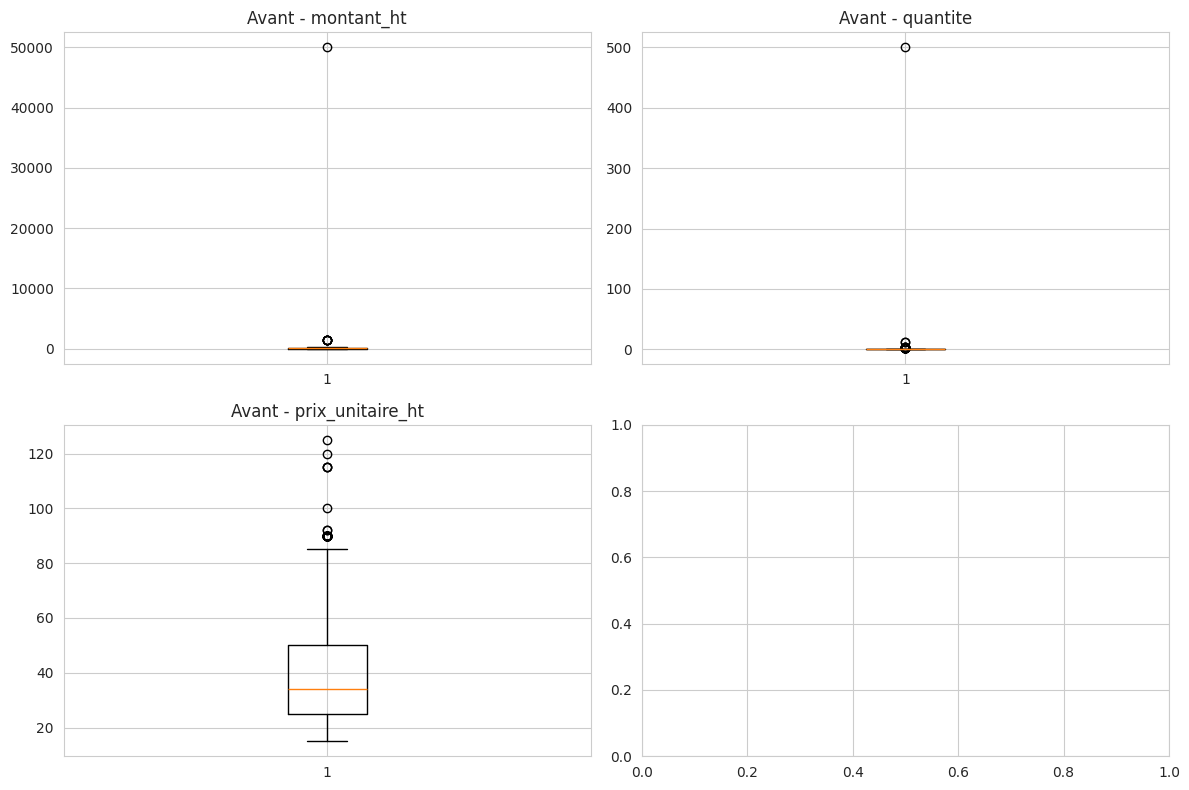

   ✅ montant_ht : 8 outliers traités (capping)
   ✅ quantite : 47 outliers traités (capping)
   ✅ prix_unitaire_ht : 64 outliers traités (capping)


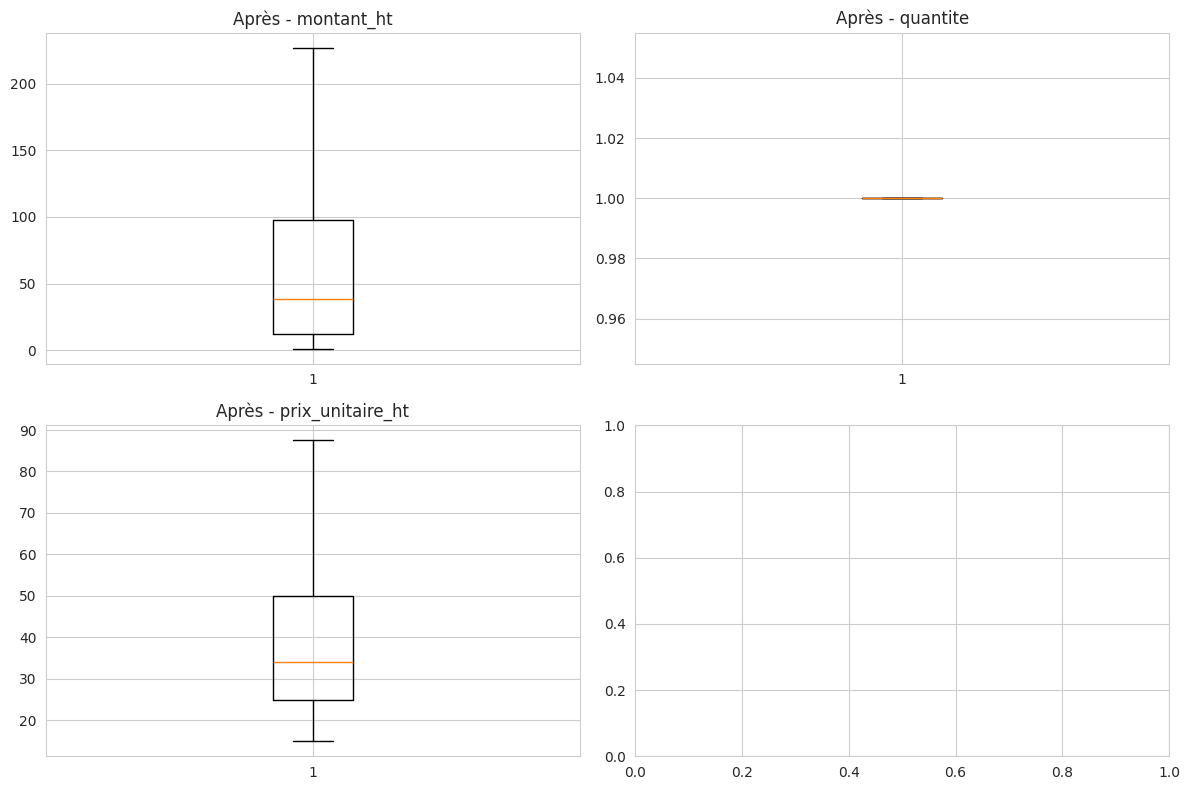


📊 Résumé du traitement des outliers :


,colonne,outliers_traites
0,montant_ht,8
1,quantite,47
2,prix_unitaire_ht,64


In [10]:
print("="*60)
print("DATA CLEANING - DETECTION ET TRAITEMENT DES OUTLIERS")
print("="*60)

# Fonction de traitement des outliers (méthode IQR)
def treat_outliers_iqr(df, column, method='cap'):
    """Traite les outliers avec méthode IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower) | (df[column] > upper)).sum()

    if method == 'cap':
        df[column] = df[column].clip(lower=lower, upper=upper)
    elif method == 'remove':
        df = df[(df[column] >= lower) & (df[column] <= upper)]

    return df, outlier_count

# Visualisation avant traitement
cols_to_check = ['montant_ht', 'quantite', 'Frais_livraison', 'prix_unitaire_ht']
cols_to_check = [c for c in cols_to_check if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(cols_to_check):
    row, col_idx = i // 2, i % 2
    axes[row, col_idx].boxplot(df[col].dropna())
    axes[row, col_idx].set_title(f'Avant - {col}')
plt.tight_layout()
plt.show()

# Traiter les outliers
outlier_summary = []
for col in cols_to_check:
    df, n_outliers = treat_outliers_iqr(df, col, method='cap')
    outlier_summary.append({'colonne': col, 'outliers_traites': n_outliers})
    print(f"   ✅ {col} : {n_outliers} outliers traités (capping)")

# Visualisation après traitement
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(cols_to_check):
    row, col_idx = i // 2, i % 2
    axes[row, col_idx].boxplot(df[col].dropna())
    axes[row, col_idx].set_title(f'Après - {col}')
plt.tight_layout()
plt.show()

print("\n📊 Résumé du traitement des outliers :")
pd.DataFrame(outlier_summary)

In [11]:
print("="*60)
print("FEATURE ENGINEERING - DOMAIN-BASED APPROACH")
print("="*60)

# 1. Variables temporelles
if 'annee' in df.columns and 'mois' in df.columns:
    df['mois_annee'] = df['annee'].astype(str) + '-' + df['mois'].astype(str).str.zfill(2)
    print("   ✅ mois_annee créé")

if 'date_complete' in df.columns:
    df['jour_semaine'] = df['date_complete'].dt.dayofweek
    df['est_weekend_calcule'] = df['jour_semaine'].isin([5, 6]).astype(int)
    print("   ✅ jour_semaine créé")

# 2. Variables financières
if 'montant_ht' in df.columns and 'quantite' in df.columns:
    df['prix_moyen_unitaire'] = df['montant_ht'] / df['quantite']
    print("   ✅ prix_moyen_unitaire créé")

if 'montant_remise' in df.columns:
    df['taux_remise'] = (df['montant_remise'] / (df['montant_ht'] + df['montant_remise'])).fillna(0)
    print("   ✅ taux_remise créé")

if 'Frais_livraison' in df.columns and 'quantite' in df.columns:
    df['frais_livraison_par_produit'] = df['Frais_livraison'] / df['quantite']
    print("   ✅ frais_livraison_par_produit créé")

# 3. Variables de performance
if 'Prix_Promo' in df.columns:
    df['est_promo'] = (df['Prix_Promo'] > 0).astype(int)
    print("   ✅ est_promo créé")

# 4. Agrégations par client (RFM-like)
client_agg = df.groupby('client_key').agg({
    'date_key': 'max',                    # Récence
    'commande_key': 'nunique',            # Fréquence
    'montant_ht': 'sum',                  # Montant
    'quantite': 'sum'                     # Quantité totale
}).rename(columns={
    'date_key': 'derniere_commande',
    'commande_key': 'nb_commandes',
    'montant_ht': 'ca_total',
    'quantite': 'qte_totale'
})

# Fusionner avec le dataset
df = df.merge(client_agg, on='client_key', how='left')
print("   ✅ Features RFM client créées")

# 5. Variables saisonnières
if 'est_ramadan' in df.columns:
    df['periode_ramadan'] = df['est_ramadan'].astype(int)
    print("   ✅ periode_ramadan créée")

# 6. Création des cibles
if 'Statut_commande' in df.columns:
    df['est_terminee'] = (df['Statut_commande'] == 'Terminée').astype(int)
    print("   ✅ cible classification créée : est_terminee")

if 'montant_ttc' in df.columns:
    df['montant_ttc_clean'] = df['montant_ttc'].fillna(df['montant_ht'] * 1.19)
    print("   ✅ cible régression créée : montant_ttc_clean")

print(f"\n📊 Nombre total de colonnes après feature engineering : {len(df.columns)}")

FEATURE ENGINEERING - DOMAIN-BASED APPROACH
   ✅ mois_annee créé
   ✅ jour_semaine créé
   ✅ prix_moyen_unitaire créé
   ✅ taux_remise créé
   ✅ Features RFM client créées
   ✅ periode_ramadan créée
   ✅ cible régression créée : montant_ttc_clean

📊 Nombre total de colonnes après feature engineering : 40


In [12]:
print("="*60)
print("PRÉPARATION POUR FEATURE SELECTION")
print("="*60)

# Sélectionner les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclure les clés et les cibles
exclude_cols = ['client_key', 'produit_key', 'date_key', 'commande_key', 'canal_key',
                'fournisseur_key', 'mp_key', 'est_terminee', 'montant_ttc_clean',
                'montant_ttc', 'montant_ht', 'montant_tva', 'revenue']

feature_cols = [c for c in numeric_cols if c not in exclude_cols]

print(f"Features candidates pour sélection : {len(feature_cols)}")
print(f"Liste : {feature_cols[:15]}...")

# Préparer X et y
X = df[feature_cols].copy()
y_classif = df['est_terminee'].copy() if 'est_terminee' in df.columns else None
y_reg = df['montant_ttc_clean'].copy() if 'montant_ttc_clean' in df.columns else None

# Gérer les NaN dans X
print(f"\nNaN dans X avant imputation : {X.isnull().sum().sum()}")
X = X.fillna(0)
print(f"NaN dans X après imputation : {X.isnull().sum().sum()}")

print(f"\n📊 Dimensions :")
print(f"   X : {X.shape}")
if y_classif is not None:
    print(f"   y_classif : {y_classif.shape} ({y_classif.nunique()} classes)")
if y_reg is not None:
    print(f"   y_reg : {y_reg.shape}")

PRÉPARATION POUR FEATURE SELECTION
Features candidates pour sélection : 19
Liste : ['vente_key', 'quantite', 'prix_unitaire_ht', 'montant_remise', 'jour', 'mois', 'trimestre', 'annee', 'semaine', 'code_date', 'jour_semaine', 'est_weekend_calcule', 'prix_moyen_unitaire', 'taux_remise', 'derniere_commande']...

NaN dans X avant imputation : 0
NaN dans X après imputation : 0

📊 Dimensions :
   X : (367, 19)
   y_reg : (367,)


In [13]:
print("="*60)
print("FEATURE SELECTION - FILTER METHODS")
print("="*60)

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif

# 1. Variance Threshold (supprimer les features quasi-constantes)
print("\n1. Variance Threshold :")
selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X)
var_support = selector_var.get_support()
var_selected = X.columns[var_support]

print(f"   Features avant : {X.shape[1]}")
print(f"   Features après (variance > 0.01) : {len(var_selected)}")
print(f"   Features supprimées : {X.shape[1] - len(var_selected)}")

# 2. Sélection basée sur la corrélation avec la cible (F-score)
if y_classif is not None:
    print("\n2. Sélection par F-score (classification) :")
    X_filter = X[var_selected]
    y_filter = y_classif

    selector_f = SelectKBest(score_func=f_classif, k=min(20, X_filter.shape[1]))
    selector_f.fit(X_filter, y_filter)

    f_scores = pd.DataFrame({
        'feature': X_filter.columns,
        'f_score': selector_f.scores_,
        'p_value': selector_f.pvalues_
    }).sort_values('f_score', ascending=False)

    print(f"   Top 10 features par F-score :")
    print(f_scores.head(10).to_string(index=False))

# 3. Mutual Information (non-linéaire)
if y_classif is not None:
    print("\n3. Sélection par Mutual Information :")
    selector_mi = SelectKBest(score_func=mutual_info_classif, k=min(20, X_filter.shape[1]))
    selector_mi.fit(X_filter, y_filter)

    mi_scores = pd.DataFrame({
        'feature': X_filter.columns,
        'mi_score': selector_mi.scores_
    }).sort_values('mi_score', ascending=False)

    print(f"   Top 10 features par Mutual Information :")
    print(mi_scores.head(10).to_string(index=False))

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_f = f_scores.head(15)
    axes[0].barh(top_f['feature'], top_f['f_score'])
    axes[0].set_title('Feature Importance - F-score')

    top_mi = mi_scores.head(15)
    axes[1].barh(top_mi['feature'], top_mi['mi_score'])
    axes[1].set_title('Feature Importance - Mutual Information')

    plt.tight_layout()
    plt.show()

FEATURE SELECTION - FILTER METHODS

1. Variance Threshold :
   Features avant : 19
   Features après (variance > 0.01) : 17
   Features supprimées : 2


In [14]:
print("="*60)
print("FEATURE SELECTION - WRAPPER METHODS (RFE)")
print("="*60)

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

if y_classif is not None:
    X_wrapper = X_filter.copy()
    y_wrapper = y_classif

    # RFE avec Random Forest
    print("\n1. RFE avec Random Forest :")
    n_features = min(15, X_wrapper.shape[1])

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rfe_rf = RFE(estimator=rf, n_features_to_select=n_features)
    rfe_rf.fit(X_wrapper, y_wrapper)

    rfe_selected = X_wrapper.columns[rfe_rf.support_]
    print(f"   Features sélectionnées : {len(rfe_selected)}")
    print(f"   Liste : {list(rfe_selected)[:10]}")

    # Visualisation
    rf_ranking = pd.DataFrame({
        'feature': X_wrapper.columns,
        'ranking': rfe_rf.ranking_
    }).sort_values('ranking')

    plt.figure(figsize=(10, 6))
    plt.barh(rf_ranking['feature'][:15], rf_ranking['ranking'][:15])
    plt.title('RFE Ranking - Random Forest (1 = meilleur)')
    plt.xlabel('Ranking')
    plt.tight_layout()
    plt.show()

FEATURE SELECTION - WRAPPER METHODS (RFE)


In [15]:
print("="*60)
print("FEATURE SELECTION - EMBEDDED METHODS")
print("="*60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

if y_classif is not None:
    X_embedded = X_filter.copy()
    y_embedded = y_classif

    # Random Forest Feature Importance
    print("\n1. Random Forest Feature Importance :")
    rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_imp.fit(X_embedded, y_embedded)

    rf_importance = pd.DataFrame({
        'feature': X_embedded.columns,
        'importance': rf_imp.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"   Top 10 features par importance :")
    print(rf_importance.head(10).to_string(index=False))

    # Sélection avec seuil (mean importance)
    selector_rf = SelectFromModel(rf_imp, threshold='mean')
    selector_rf.fit(X_embedded, y_embedded)
    rf_selected = X_embedded.columns[selector_rf.get_support()]

    print(f"\n   Features sélectionnées (importance > moyenne) : {len(rf_selected)}")
    print(f"   {list(rf_selected)[:10]}")

    # Visualisation
    plt.figure(figsize=(10, 6))
    top_rf = rf_importance.head(15)
    plt.barh(top_rf['feature'], top_rf['importance'])
    plt.title('Random Forest Feature Importance (Embedded)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

FEATURE SELECTION - EMBEDDED METHODS


In [16]:
print("="*60)
print("SYNTHÈSE DES FEATURE SELECTION")
print("="*60)

if y_classif is not None:
    # Compilation de toutes les méthodes
    all_selected = {
        'Filter (F-score top10)': set(f_scores.head(10)['feature']),
        'Filter (MI top10)': set(mi_scores.head(10)['feature']),
        'Wrapper (RFE-RF)': set(rfe_selected),
        'Embedded (RF)': set(rf_selected)
    }

    # Tableau récapitulatif
    summary_df = pd.DataFrame({
        'Méthode': list(all_selected.keys()),
        'Nb_features': [len(v) for v in all_selected.values()]
    })
    print("\n📊 Nombre de features sélectionnées par méthode :")
    print(summary_df.to_string(index=False))

    # Intersection de toutes les méthodes
    consensus_all = set.intersection(*all_selected.values())
    print(f"\n✅ Features sélectionnées par TOUTES les méthodes : {len(consensus_all)}")
    if len(consensus_all) > 0:
        print(f"   {list(consensus_all)}")

    # Sélection finale : features présentes dans au moins 2 méthodes
    method_count = {}
    all_features = set.union(*all_selected.values())
    for feature in all_features:
        count = sum(1 for selected in all_selected.values() if feature in selected)
        method_count[feature] = count

    final_features = [f for f, c in method_count.items() if c >= 2]
    print(f"\n🎯 Features finales sélectionnées (≥ 2 méthodes) : {len(final_features)}")
    print(f"   {final_features[:15]}")

    # Visualisation du consensus
    method_counts_series = pd.Series(method_count).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(method_counts_series)), method_counts_series.values)
    plt.yticks(range(len(method_counts_series)), method_counts_series.index)
    plt.xlabel('Nombre de méthodes ayant sélectionné la feature')
    plt.title('Consensus des méthodes de Feature Selection')
    plt.tight_layout()
    plt.show()

SYNTHÈSE DES FEATURE SELECTION


In [17]:
print("="*60)
print("ENCODING & SCALING")
print("="*60)

from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Label Encoding pour les variables ordinales
label_encoders = {}
ordinal_cols = ['saison', 'Categorie', 'Type_client']

for col in ordinal_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f"   ✅ {col} encodé (LabelEncoder)")

# 2. One-Hot Encoding pour les variables nominales
nominal_cols = ['Mode_paiement', 'type_canal', 'physique_ou_digital', 'Gouvernorat']
nominal_cols = [c for c in nominal_cols if c in df.columns]

if nominal_cols:
    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
    print(f"   ✅ One-Hot Encoding : {len(nominal_cols)} colonnes transformées")

# 3. Scaling des colonnes numériques
numeric_cols_for_scaling = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclure les clés et cibles
exclude_scaler = ['client_key', 'produit_key', 'date_key', 'commande_key', 'canal_key',
                  'est_terminee', 'montant_ttc_clean', 'montant_ttc', 'revenue']
numeric_cols_for_scaling = [c for c in numeric_cols_for_scaling if c not in exclude_scaler]

print(f"\nColonnes à scaler : {len(numeric_cols_for_scaling)}")

# Appliquer StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols_for_scaling] = scaler.fit_transform(df[numeric_cols_for_scaling])

print("✅ StandardScaler appliqué")

# Vérification
print(f"\n📊 Statistiques après scaling :")
print(df_scaled[numeric_cols_for_scaling[:5]].describe().round(2))

ENCODING & SCALING
   ✅ saison encodé (LabelEncoder)
   ✅ One-Hot Encoding : 2 colonnes transformées

Colonnes à scaler : 22
✅ StandardScaler appliqué

📊 Statistiques après scaling :
       vente_key  quantite  prix_unitaire_ht  montant_ht  montant_tva
count     367.00     367.0            367.00      367.00       367.00
mean        0.00       0.0             -0.00        0.00        -0.00
std         1.00       0.0              1.00        1.00         1.00
min        -2.74       0.0             -1.20       -1.11        -0.08
25%        -0.64       0.0             -0.78       -0.88        -0.08
50%         0.11       0.0             -0.40       -0.34        -0.07
75%         0.89       0.0              0.27        0.90        -0.04
max         1.58       0.0              1.83        3.57        19.07


In [18]:
print("="*60)
print("SAUVEGARDE DU DATASET")
print("="*60)

# Monter Drive pour sauvegarder (optionnel)
from google.colab import drive
drive.mount('/content/drive')

# Sauvegarder les versions
df_scaled.to_csv('/content/drive/MyDrive/Projet_Sougui/data_clean_scaled.csv', index=False)
df.to_csv('/content/drive/MyDrive/Projet_Sougui/data_clean_non_scaled.csv', index=False)

# Sauvegarder le scaler et les encodeurs
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/Projet_Sougui/scaler.pkl')
joblib.dump(label_encoders, '/content/drive/MyDrive/Projet_Sougui/label_encoders.pkl')

print("✅ Dataset sauvegardé")
print(f"   Shape final : {df_scaled.shape}")
print(f"   Colonnes : {len(df_scaled.columns)}")
print(f"   NaN restants : {df_scaled.isnull().sum().sum()}")

SAUVEGARDE DU DATASET
Mounted at /content/drive


OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/Projet_Sougui'

In [19]:
print("="*60)
print("BILAN FINAL - DATA PREPARATION")
print("="*60)

print("""
┌─────────────────────────────────────────────────────────────┐
│  DATA CLEANING                                              │
├─────────────────────────────────────────────────────────────┤
│  ✅ Suppression des anomalies (produits 0, quantités 0)     │
│  ✅ Gestion des valeurs manquantes (fillna stratégique)     │
│  ✅ Correction des types (dates, catégories, floats)        │
│  ✅ Traitement des outliers (méthode IQR avec capping)      │
├─────────────────────────────────────────────────────────────┤
│  FEATURE ENGINEERING                                        │
├─────────────────────────────────────────────────────────────┤
│  ✅ Variables temporelles (mois_annee, jour_semaine)        │
│  ✅ Variables financières (prix_moyen, taux_remise)         │
│  ✅ Variables RFM client (récence, fréquence, montant)      │
│  ✅ Variables saisonnières (Ramadan, weekend)               │
│  ✅ Création des cibles (est_terminee, montant_ttc_clean)   │
├─────────────────────────────────────────────────────────────┤
│  FEATURE SELECTION                                          │
├─────────────────────────────────────────────────────────────┤
│  ✅ Filter methods (Variance, F-score, Mutual Information)  │
│  ✅ Wrapper methods (RFE avec Random Forest)                │
│  ✅ Embedded methods (Random Forest importance)             │
│  ✅ Consensus final (features sélectionnées)                │
├─────────────────────────────────────────────────────────────┤
│  ENCODING & SCALING                                         │
├─────────────────────────────────────────────────────────────┤
│  ✅ Label Encoding (ordinal)                                │
│  ✅ One-Hot Encoding (nominal)                              │
│  ✅ StandardScaler (données normalisées)                    │
└─────────────────────────────────────────────────────────────┘
""")

print(f"\n📊 Dataset final prêt pour le Machine Learning !")
print(f"   Lignes : {len(df_scaled):,}")
print(f"   Colonnes : {len(df_scaled.columns)}")
print(f"   Shape : {df_scaled.shape}")
print(f"   NaN : {df_scaled.isnull().sum().sum()}")

# Vérification finale
if 'est_terminee' in df_scaled.columns:
    print(f"\n✅ Cible classification : est_terminee")
    print(f"   Distribution : {df_scaled['est_terminee'].value_counts().to_dict()}")

if 'montant_ttc_clean' in df_scaled.columns:
    print(f"\n✅ Cible régression : montant_ttc_clean")
    print(f"   Min : {df_scaled['montant_ttc_clean'].min():.2f}")
    print(f"   Max : {df_scaled['montant_ttc_clean'].max():.2f}")

BILAN FINAL - DATA PREPARATION

┌─────────────────────────────────────────────────────────────┐
│  DATA CLEANING                                              │
├─────────────────────────────────────────────────────────────┤
│  ✅ Suppression des anomalies (produits 0, quantités 0)     │
│  ✅ Gestion des valeurs manquantes (fillna stratégique)     │
│  ✅ Correction des types (dates, catégories, floats)        │
│  ✅ Traitement des outliers (méthode IQR avec capping)      │
├─────────────────────────────────────────────────────────────┤
│  FEATURE ENGINEERING                                        │
├─────────────────────────────────────────────────────────────┤
│  ✅ Variables temporelles (mois_annee, jour_semaine)        │
│  ✅ Variables financières (prix_moyen, taux_remise)         │
│  ✅ Variables RFM client (récence, fréquence, montant)      │
│  ✅ Variables saisonnières (Ramadan, weekend)               │
│  ✅ Création des cibles (est_terminee, montant_ttc_clean)   │
├────────────────